In [159]:
import os
# Вимкнення зайвих логів TensorFlow тут щоб потім не вказувати це в кожному місці
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping

In [160]:
BASE_DIR = Path.cwd()
file_name = 'pokedex_b.csv'
DATA_PATH = BASE_DIR / 'data' / file_name
RANDOM_SEED = 42
TEST_SIZE = 0.2

try:
    df = pd.read_csv(DATA_PATH)
    print("File loaded successfully.")
except FileNotFoundError:
    print("File not found. Please check the file path and name.")


File loaded successfully.


In [161]:
from IPython.display import display, Markdown
display(Markdown(f"### Shape: {df.shape[0]} rows, {df.shape[1]} columns"))
display(df.head())

display(Markdown("### Info"))
df.info()

### Shape: 1402 rows, 14 columns

,pokedex_number,name,attack,defense,height_m,hp,percentage_male,sp_attack,sp_defense,speed,type,weight_kg,generation,is_legendary
0,144,Articuno,85,100,1.7,90,0.0,95,125,85,ice,55.4,1,1
1,145,Zapdos,90,85,1.6,90,0.0,125,90,100,electric,52.6,1,1
2,146,Moltres,100,90,2.0,90,0.0,125,85,90,fire,60.0,1,1
3,150,Mewtwo,150,70,2.0,106,0.0,194,120,140,psychic,122.0,1,1
4,151,Mew,100,100,0.4,100,0.0,100,100,100,psychic,4.0,1,1


### Info

<class 'pandas.DataFrame'>
RangeIndex: 1402 entries, 0 to 1401
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pokedex_number   1402 non-null   int64  
 1   name             1402 non-null   str    
 2   attack           1402 non-null   int64  
 3   defense          1402 non-null   int64  
 4   height_m         1402 non-null   float64
 5   hp               1402 non-null   int64  
 6   percentage_male  1402 non-null   float64
 7   sp_attack        1402 non-null   int64  
 8   sp_defense       1402 non-null   int64  
 9   speed            1402 non-null   int64  
 10  type             1402 non-null   str    
 11  weight_kg        1402 non-null   float64
 12  generation       1402 non-null   int64  
 13  is_legendary     1402 non-null   int64  
dtypes: float64(3), int64(9), str(2)
memory usage: 153.5 KB


Перевіряємо, наскільки збалансована кількість зразків кожного класу. В нашому випадку доля класу приблизно однаковою.

In [162]:
df['is_legendary'].value_counts(normalize=True)

is_legendary
0    0.507846
1    0.492154
Name: proportion, dtype: float64

In [163]:
df_cleaned = df.drop(columns=['name', 'pokedex_number'])
df_cleaned.head()

,attack,defense,height_m,hp,percentage_male,sp_attack,sp_defense,speed,type,weight_kg,generation,is_legendary
0,85,100,1.7,90,0.0,95,125,85,ice,55.4,1,1
1,90,85,1.6,90,0.0,125,90,100,electric,52.6,1,1
2,100,90,2.0,90,0.0,125,85,90,fire,60.0,1,1
3,150,70,2.0,106,0.0,194,120,140,psychic,122.0,1,1
4,100,100,0.4,100,0.0,100,100,100,psychic,4.0,1,1


In [164]:
df_cleaned['type'] = pd.factorize(df_cleaned['type'])[0]
df_cleaned.head()

,attack,defense,height_m,hp,percentage_male,sp_attack,sp_defense,speed,type,weight_kg,generation,is_legendary
0,85,100,1.7,90,0.0,95,125,85,0,55.4,1,1
1,90,85,1.6,90,0.0,125,90,100,1,52.6,1,1
2,100,90,2.0,90,0.0,125,85,90,2,60.0,1,1
3,150,70,2.0,106,0.0,194,120,140,3,122.0,1,1
4,100,100,0.4,100,0.0,100,100,100,3,4.0,1,1


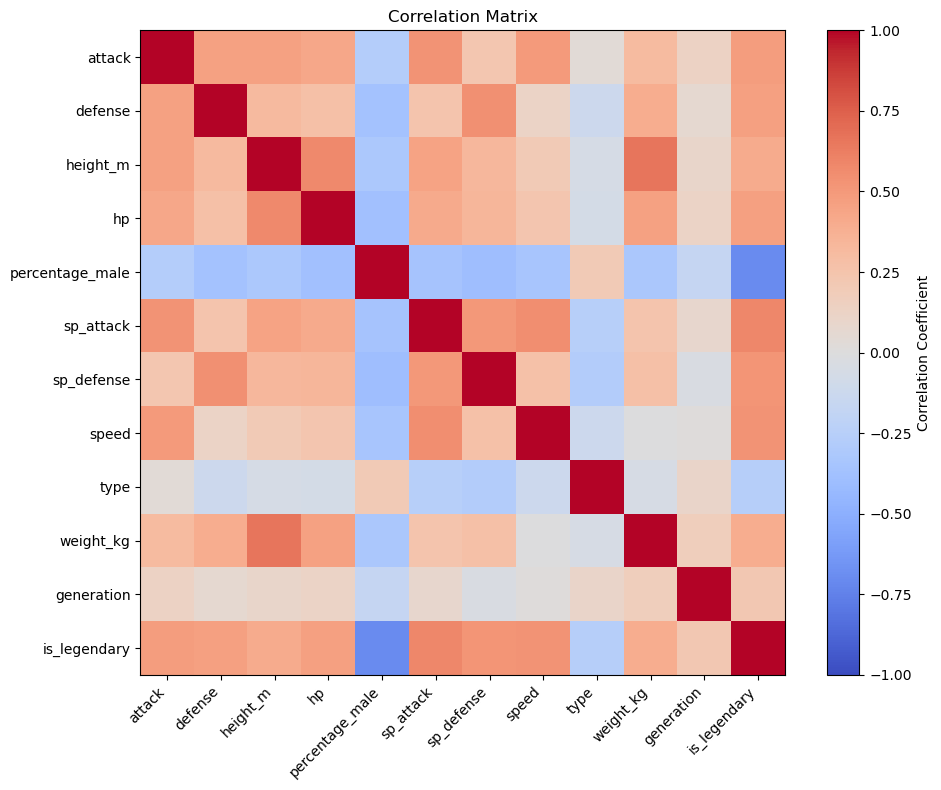

In [165]:
plt.figure(figsize=(10, 8))
plt.imshow(df_cleaned.corr(), cmap='coolwarm', interpolation='nearest', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Coefficient')
plt.title('Correlation Matrix')

# Додаємо назви колонок на осі
columns = df_cleaned.columns
plt.xticks(range(len(columns)), columns, rotation=45, ha='right')
plt.yticks(range(len(columns)), columns)

plt.tight_layout()
plt.show()

In [166]:
X = df_cleaned.drop(columns=['is_legendary']).values
y = df_cleaned['is_legendary'].values
y_ohe = to_categorical(y, num_classes=2)

X_train, X_test, y_train, y_test = train_test_split(X, y_ohe, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_ohe)
X_train

array([[ 40. ,  50. ,   0.6, ...,   3. ,   8. ,   5. ],
       [145. ,  90. ,   1.5, ...,   8. ,  68. ,   5. ],
       [ 52. ,  43. ,   0.6, ...,   2. ,   8.5,   1. ],
       ...,
       [ 75. , 115. ,   2. , ...,   4. , 187. ,   2. ],
       [124. ,  80. ,   2.8, ...,   8. , 330. ,   5. ],
       [ 68. ,  72. ,   1.5, ...,   2. ,  81.5,   6. ]], shape=(1121, 11))

In [167]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [168]:
model = Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    Dense(16, activation='relu', kernel_regularizer= 'l2'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(4, activation='selu', kernel_regularizer= 'l2'),
    Dense(2, activation='softmax', kernel_regularizer= 'l2') 
])

In [169]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 2)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 334 (1.30 KB)

 Trainable params: 302 (1.18 KB)

 Non-trainable params: 32 (128.00 B)

In [170]:
early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=64,          # Кількість епох (можна змінити після аналізу графіка)
    batch_size=16,      # Розмір пакету
    validation_split=0.1, # Виділяємо частину train для валідації в процесі
    verbose=1,
    callbacks=[early]
)

Epoch 1/64
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6687 - loss: 0.9332 - val_accuracy: 0.8319 - val_loss: 0.8253
Epoch 2/64
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8075 - loss: 0.7546 - val_accuracy: 0.9027 - val_loss: 0.7011
Epoch 3/64
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8651 - loss: 0.6407 - val_accuracy: 0.9115 - val_loss: 0.5845
Epoch 4/64
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8839 - loss: 0.5609 - val_accuracy: 0.9292 - val_loss: 0.4871
Epoch 5/64
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9167 - loss: 0.4765 - val_accuracy: 0.9292 - val_loss: 0.4187
Epoch 6/64
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9038 - loss: 0.4519 - val_accuracy: 0.9469 - val_loss: 0.3744
Epoch 7/64
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9127 - loss: 0.4056 - val_accuracy: 0.9469 - val_loss: 0.3467
Epoch 8/64
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9315 - loss: 0.3587 - val_accuracy: 0.9558 - val_loss

In [171]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(loss, accuracy)

0.10319450497627258 0.9964413046836853


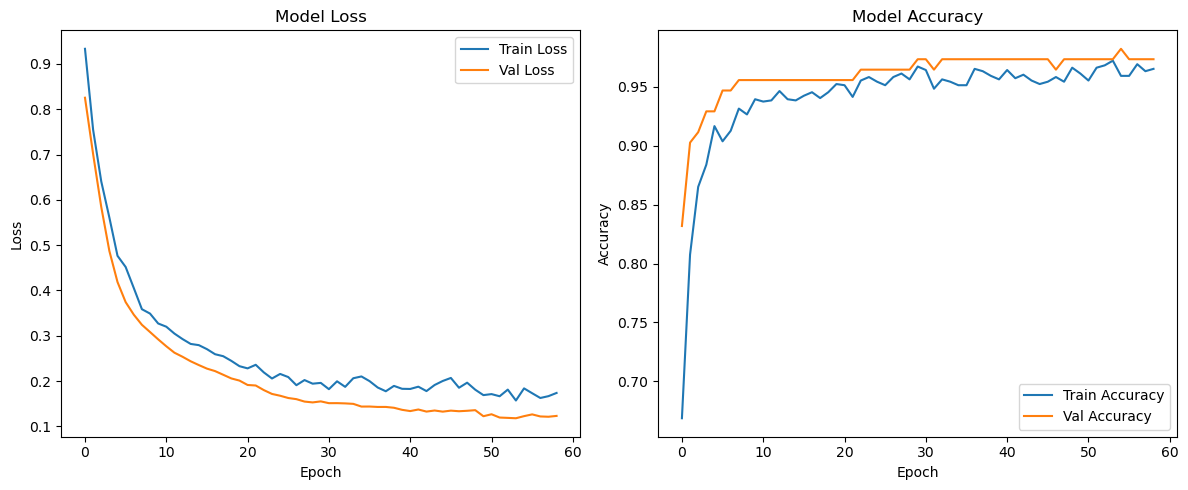

In [172]:
plt.figure(figsize=(12, 5))

# Графік втрат (Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Графік точності (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [182]:
import random

# Вибираємо випадковий індекс з тестової вибірки
random_idx = random.randint(0, X_test.shape[0] - 1)
sample = X_test[random_idx].reshape(1, -1) # Решейп для подачі в модель (1, n_features)

# Отримуємо передбачення (ймовірності для кожного класу)
prediction_probs = model.predict(sample, verbose=0)
predicted_class = np.argmax(prediction_probs) # Індекс класу з найвищою ймовірністю
confidence = np.max(prediction_probs) * 100   # Максимальна ймовірність у відсотках

true_class = np.argmax(y_test[random_idx]) # Істинний клас (зворотнє перетворення з OHE)

print(f"\n--- Результат передбачення для зразка #{random_idx} ---")
print(f"Істинний клас: {true_class}")
print(f"Передбачено клас {predicted_class} з достовірністю {confidence:.2f}%")


--- Результат передбачення для зразка #22 ---
Істинний клас: 0
Передбачено клас 0 з достовірністю 99.98%


In [174]:
model.save('islegendary.keras')